In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm
from matplotlib.backends.backend_pdf import PdfPages
import argparse
import sys
from matplotlib import rc, rcParams
import matplotlib.ticker as mticker

# global plotting settings
FONTSIZE = 18 #18 standart 24 for three plots in a row

# matplotlib settings
plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
plt.rc("axes", titlesize=FONTSIZE)
# plt.rc("text.latex", preamble=r"\usepackage{amsmath}\usepackage[bitstream-charter]{mathdesign}")
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage{amsmath}
\usepackage[bitstream-charter]{mathdesign}
\DeclareSymbolFont{usualmathcal}{OMS}{cmsy}{m}{n}
\DeclareSymbolFontAlphabet{\mathcal}{usualmathcal}
"""
)
plt.rc("text", usetex=True)
# rc('xtick', labelsize=FONTSIZE)
rc('ytick', labelsize=FONTSIZE)

rcParams["errorbar.capsize"] = 7.0
rcParams['legend.frameon']=False
rcParams['legend.handlelength']=1.5


In [2]:
# load arrays
replicas = np.load("../results/gp/gibbs_kernel/fstar_replicas.npy")
npz = np.load("../results/gp/gibbs_kernel/fstar_posterior_summary.npz")

true = npz["xt3_true_star"]
print(npz.keys)
xgrid = npz["x_star"]

# prediction and uncertainty
pred = replicas.mean(axis=0)
sigma = replicas.std(axis=0)

# statistics
t = (pred - true) / sigma
delta = (pred - true) / true
residuals_gibbs = true-pred

<bound method Mapping.keys of NpzFile '../results/gp/gibbs_kernel/fstar_posterior_summary.npz' with keys: x_star, mean_curve, lo68, hi68, lo95...>


In [5]:
replicas2 = np.load("../results/gp/rbf_kernel/fstar_replicas.npy")
npz2 = np.load("../results/gp/rbf_kernel/fstar_posterior_summary.npz")

true2 = npz["xt3_true_star"]

# prediction and uncertainty
pred2 = replicas2.mean(axis=0)
sigma2 = replicas2.std(axis=0)

# statistics
t2 = (pred2 - true2) / sigma2
delta2 = (pred2 - true2) / true2
residuals_rbf = true2-pred2

In [6]:
replicas_matern05 = np.load("../results/gp/matern_kernel_nu0.5/fstar_replicas.npy")
npz_matern05 = np.load("../results/gp/matern_kernel_nu0.5/fstar_posterior_summary.npz")

true_matern05 = npz_matern05["xt3_true_star"]
# prediction and uncertainty
pred_matern05 = replicas_matern05.mean(axis=0)
sigma_matern05 = replicas_matern05.std(axis=0)
# statistics
t_matern05 = (pred_matern05 - true_matern05) / sigma_matern05
delta_matern05 = (pred_matern05 - true_matern05) / true_matern05
residuals_matern05 = true_matern05 - pred_matern05

replicas_matern15 = np.load("../results/gp/matern_kernel_nu1.5/fstar_replicas.npy")
npz_matern15 = np.load("../results/gp/matern_kernel_nu1.5/fstar_posterior_summary.npz")

true_matern15 = npz_matern15["xt3_true_star"]
# prediction and uncertainty
pred_matern15 = replicas_matern15.mean(axis=0)
sigma_matern15 = replicas_matern15.std(axis=0)
# statistics
t_matern15 = (pred_matern15 - true_matern15) / sigma_matern15
delta_matern15 = (pred_matern15 - true_matern15) / true_matern15
residuals_matern15 = true_matern15 - pred_matern15

replicas_matern25 = np.load("../results/gp/matern_kernel_nu2.5/fstar_replicas.npy")
npz_matern25 = np.load("../results/gp/matern_kernel_nu2.5/fstar_posterior_summary.npz")

true_matern25 = npz_matern25["xt3_true_star"]
# prediction and uncertainty
pred_matern25 = replicas_matern25.mean(axis=0)
sigma_matern25 = replicas_matern25.std(axis=0)
# statistics
t_matern25 = (pred_matern25 - true_matern25) / sigma_matern25
delta_matern25 = (pred_matern25 - true_matern25) / true_matern25
residuals_matern25 = true_matern25 - pred_matern25

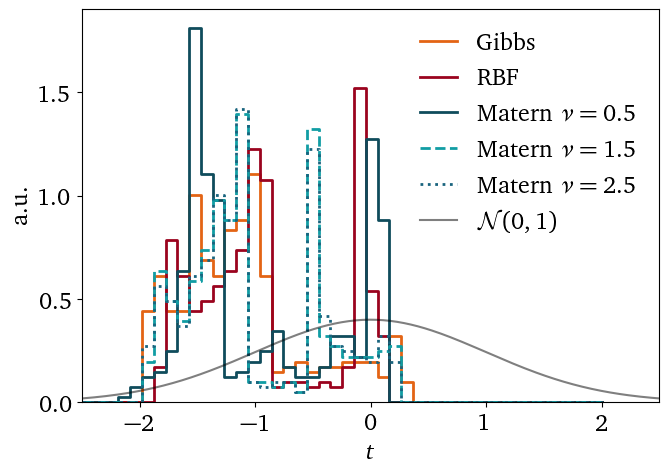

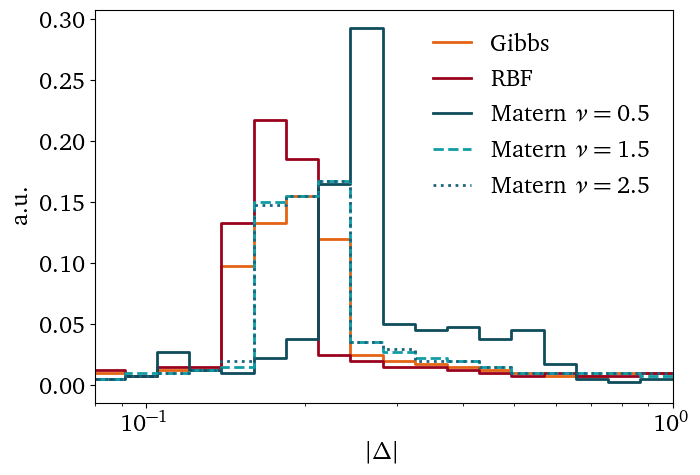

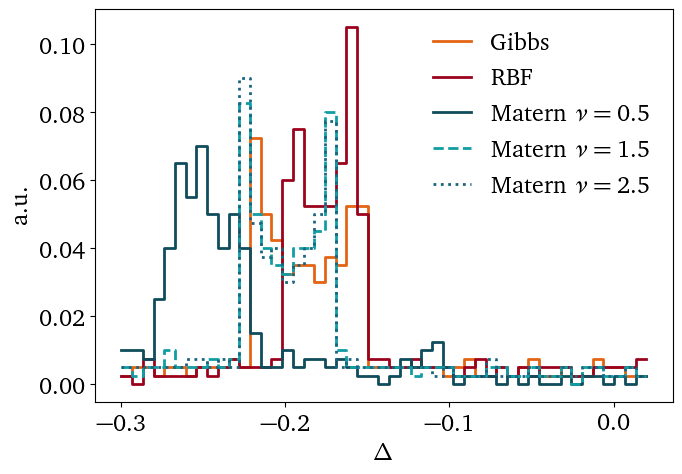

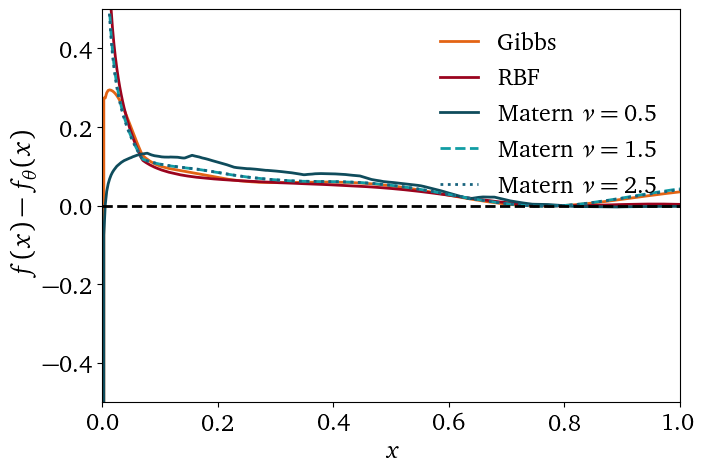

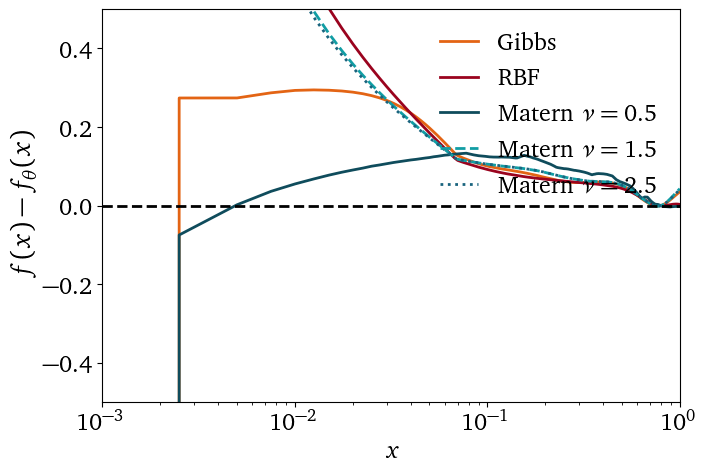

In [9]:
bins = np.linspace(-1, 1, 21)
q = np.linspace(-5, 5, 500)
gauss = norm.pdf( q, 0, 1) # gaussian pdf in (-3, 3) 
dup = lambda a: np.append(a, a[-1])
logbins = np.logspace(-3, 0, 50)

with PdfPages("kernel_bias.pdf") as pdf:
    fig, axs = plt.subplots( 1, 1, figsize=(7,5))
    fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
    hist1, bins = np.histogram(t.flatten(), bins=np.linspace(-3, 2, 50), density=True)
    hist2, bins = np.histogram(t2.flatten(), bins=np.linspace(-3, 2, 50), density=True)
    hist3, bins = np.histogram(t_matern05.flatten(), bins=np.linspace(-3, 2, 50), density=True)
    hist4, bins = np.histogram(t_matern15.flatten(), bins=np.linspace(-3, 2, 50), density=True)
    hist5, bins = np.histogram(t_matern25.flatten(), bins=np.linspace(-3, 2, 50), density=True)
    axs.step(bins, dup(hist1), color='#E36414', linestyle='solid', label='Gibbs', where='post', linewidth=2)
    axs.step(bins, dup(hist2), color='#9A031E', linestyle='solid', label='RBF', where='post', linewidth=2)
    axs.step(bins, dup(hist3), color='#0F4C5C', linestyle='solid', label='Matern $\\nu=0.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist4), color='#119DA4', linestyle='dashed', label='Matern $\\nu=1.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist5), color='#19647E', linestyle='dotted', label='Matern $\\nu=2.5$', where='post', linewidth=2)
    axs.plot(q, gauss, color='black', alpha=.5, label='$\\mathcal{N}(0,1)$')
    axs.set_xlabel('$t$')
    axs.set_ylabel('a.u.')
    axs.set_xlim([-2.5, 2.5])
    axs.set_ylim(0.0)
    axs.legend(frameon=False, loc='upper right')
    #axs.text(0.1, 0.97, "$u\\bar{u}g$", fontsize=FONTSIZE, ha="right", va="top", transform=axs.transAxes)
    plt.show()
    pdf.savefig(fig)
    plt.close()

    fig, axs = plt.subplots( 1, 1, figsize=(7,5))
    fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
    hist1, bins = np.histogram(np.abs(delta).flatten(), bins=logbins)
    hist1 = hist1 / len(delta)
    hist2, bins = np.histogram(np.abs(delta2).flatten(), bins=logbins)
    hist2 = hist2 / len(delta2)
    hist3, bins = np.histogram(np.abs(delta_matern05).flatten(), bins=logbins)
    hist3 = hist3 / len(delta_matern05)
    hist4, bins = np.histogram(np.abs(delta_matern15).flatten(), bins=logbins)
    hist4 = hist4 / len(delta_matern15)
    hist5, bins = np.histogram(np.abs(delta_matern25).flatten(), bins=logbins)
    hist5 = hist5 / len(delta_matern25)
    axs.step(bins, dup(hist1), color='#E36414', linestyle='solid', label='Gibbs', where='post', linewidth=2)
    axs.step(bins, dup(hist2), color='#9A031E', linestyle='solid', label='RBF', where='post', linewidth=2)
    axs.step(bins, dup(hist3), color='#0F4C5C', linestyle='solid', label='Matern $\\nu=0.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist4), color='#119DA4', linestyle='dashed', label='Matern $\\nu=1.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist5), color='#19647E', linestyle='dotted', label='Matern $\\nu=2.5$', where='post', linewidth=2)
    axs.set_xlabel('$|\\Delta|$')
    axs.set_xscale('log')
    axs.set_xlim([8e-2, 1e0])
#     axs.set_ylim([0.0, 0.066])
    axs.set_ylabel('a.u.')
    axs.legend(frameon=False, loc='upper right')
    plt.show()
    pdf.savefig(fig)
    plt.close()

    fig, axs = plt.subplots( 1, 1, figsize=(7,5))
    fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
    hist1, bins = np.histogram((delta).flatten(), bins=np.linspace(-3e-1, 2e-2, 50))
    hist1 = hist1 / len(delta)
    hist2, bins = np.histogram((delta2).flatten(), bins=np.linspace(-3e-1, 2e-2, 50))
    hist2 = hist2 / len(delta2)
    hist3, bins = np.histogram((delta_matern05).flatten(), bins=np.linspace(-3e-1, 2e-2, 50))
    hist3 = hist3 / len(delta_matern05)
    hist4, bins = np.histogram((delta_matern15).flatten(), bins=np.linspace(-3e-1, 2e-2, 50))
    hist4 = hist4 / len(delta_matern15)
    hist5, bins = np.histogram((delta_matern25).flatten(), bins=np.linspace(-3e-1, 2e-2, 50))
    hist5 = hist5 / len(delta_matern25)
    axs.step(bins, dup(hist1), color='#E36414', linestyle='solid', label='Gibbs', where='post', linewidth=2)
    axs.step(bins, dup(hist2), color='#9A031E', linestyle='solid', label='RBF', where='post', linewidth=2)
    axs.step(bins, dup(hist3), color='#0F4C5C', linestyle='solid', label='Matern $\\nu=0.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist4), color='#119DA4', linestyle='dashed', label='Matern $\\nu=1.5$', where='post', linewidth=2)
    axs.step(bins, dup(hist5), color='#19647E', linestyle='dotted', label='Matern $\\nu=2.5$', where='post', linewidth=2)
    axs.set_xlabel('$\\Delta$')
    # axs.set_xscale('log')
    # axs.set_xlim([8e-4, 1e4])
#     axs.set_ylim([0.0, 0.066])
    axs.set_ylabel('a.u.')
    axs.legend(frameon=False, loc='upper right')
    plt.show()
    pdf.savefig(fig)
    plt.close()

    
    fig, axs = plt.subplots( 1, 1, figsize=(7,5))
    fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
    axs.plot(xgrid, residuals_gibbs, '#E36414', linewidth=2, label='Gibbs')
    axs.plot(xgrid, residuals_rbf, '#9A031E', linewidth=2, label='RBF')
    axs.plot(xgrid, residuals_matern05, '#0F4C5C', linestyle='solid', linewidth=2, label='Matern $\\nu=0.5$')
    axs.plot(xgrid, residuals_matern15, '#119DA4', linestyle='dashed', linewidth=2, label='Matern $\\nu=1.5$')
    axs.plot(xgrid, residuals_matern25, '#19647E', linestyle='dotted', linewidth=2, label='Matern $\\nu=2.5$')
    axs.axhline(0, linestyle='--', color='black', linewidth=2)
    axs.set_xlabel('$x$')
    axs.set_ylabel('$f(x) - f_\\theta(x)$', fontsize=20)
    axs.legend(frameon=False, loc='upper right')
    axs.set_ylim([-0.5, 0.5])
    axs.set_xlim([0, 1.0])
    plt.show()
    pdf.savefig(fig)
    plt.close()

    fig, axs = plt.subplots( 1, 1, figsize=(7,5))
    fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
    axs.plot(xgrid, residuals_gibbs, '#E36414', linewidth=2, label='Gibbs')
    axs.plot(xgrid, residuals_rbf, '#9A031E', linewidth=2, label='RBF')
    axs.plot(xgrid, residuals_matern05, '#0F4C5C', linestyle='solid', linewidth=2, label='Matern $\\nu=0.5$')
    axs.plot(xgrid, residuals_matern15, '#119DA4', linestyle='dashed', linewidth=2, label='Matern $\\nu=1.5$')
    axs.plot(xgrid, residuals_matern25, '#19647E', linestyle='dotted', linewidth=2, label='Matern $\\nu=2.5$')
    axs.axhline(0, linestyle='--', color='black', linewidth=2)
    axs.set_xlabel('$x$')
    axs.set_ylabel('$f(x) - f_\\theta(x)$', fontsize=20)
    axs.legend(frameon=False, loc='upper right')
    axs.set_xscale('log')
    axs.set_ylim([-0.5, 0.5])
    axs.set_xlim([1e-3, 1.0])
    plt.show()
    pdf.savefig(fig)
    plt.close()